In [2]:
import matplotlib
matplotlib.use("Agg")

In [3]:
import matplotlib.pyplot as plt
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.tools.distribution_parametrization import MozaikExtendedParameterSet, load_parameters
from mozaik.storage.queries import *
import numpy as np
import logging
import sys
from mozaik.analysis.analysis import *
from mozaik.storage.datastore import DataStoreView
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
from skimage.transform import resize
import pickle
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

In [8]:
path = "/home/rozsa/dev/retina_only/mozaik-models/real_validation_experiments/20250812-170852[param.defaults]CombinationParamSearch{trial:[0]}/Kara et al. 2000_Figure 4C/"
data_store = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
    replace=False,
)

# stepcurrentsource
path = "/home/rozsa/dev/retina_only/mozaik-models/real_validation_experiments/20250808-160437[param.defaults]CombinationParamSearch{trial:32}/Kara et al. 2000_Figure 4C/"
ds2 = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
    replace=False,
)
#sheet = "X_ON"
sheet = "X_OFF"

dsv_sc = param_filter_query(ds2, st_name="FullfieldDriftingSinusoidalGrating", sheet_name=sheet)
dsv_orig = param_filter_query(data_store, st_name="FullfieldDriftingSinusoidalGrating", sheet_name=sheet)

In [9]:
%matplotlib inline

def order_segments(data_store, sheet):
    segs = param_filter_query(
        data_store, st_name="FullfieldDriftingSinusoidalGrating", sheet_name=sheet
    ).get_segments()
    segs.extend(
        param_filter_query(data_store, sheet_name=sheet).get_segments(null=True)
    )
    
    datetimes = [seg.rec_datetime for seg in segs]
    indices = sorted(range(len(segs)), key=datetimes.__getitem__)

    sorted_segs = [segs[indices[i]] for i in range(len(indices))]
    return sorted_segs


segs = order_segments(data_store, sheet)
segs2 = order_segments(ds2, sheet)

# long_rasterplot(segs)


3.695
6.285


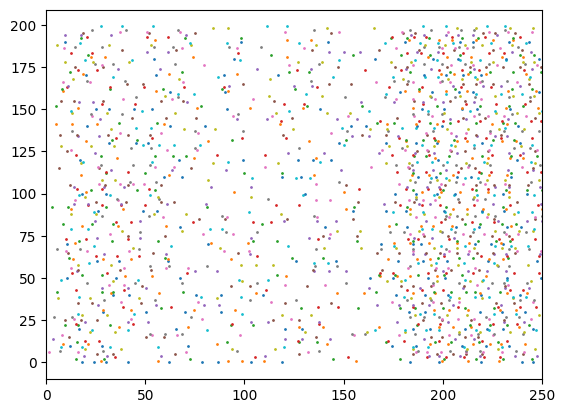

2.165
5.765


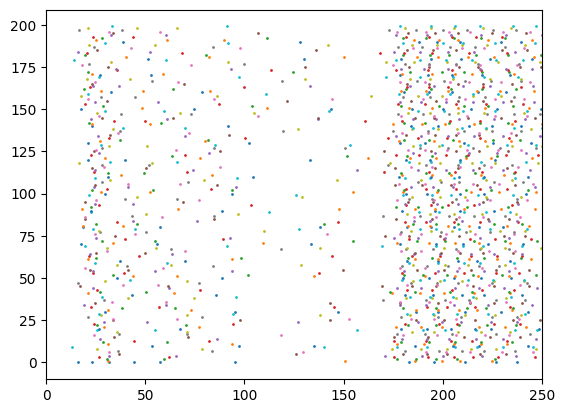

In [12]:
def long_rasterplot(segs):
    curr_times = [0, 0]
    stimes = [[]] * len(segs[0].get_spiketrains())
    for seg in segs:
        st = seg.get_spiketrains()
        for i in range(len(st)):
            # print(np.array(st[i])+curr_time)
            stimes[i].append(np.array(st[i]) + curr_times[i])
            # print(np.array(st[i].t_stop-st[i].t_start))
            curr_times[i] += np.array(st[i].t_stop - st[i].t_start)
    stimes = [np.hstack(stime) for stime in stimes]
    for i in range(len(stimes)):
        s = stimes[i]
        plt.plot(s, np.ones_like(s) * i, "o", ms=1)
    plt.xlim(0,3000)
    plt.show()


def grouped_rasterplot(segs):
    for i in range(len(segs) // 2):
        blank_st = segs[i * 2].get_spiketrains()[0]
        stim_st = np.array(segs[i * 2 + 1].get_spiketrains()[0] + blank_st.t_stop - blank_st.t_start)
        stimes = np.hstack([np.array(blank_st),stim_st])
        plt.plot(stimes,np.ones_like(stimes)*i,'o',ms=1,label=ParameterSet(segs[i*2].annotations['stimulus'])['contrast'])
    print(np.mean([len(segs[i * 2].get_spiketrains()[0]) for i in range(len(segs) // 2)]))
    print(np.mean([len(segs[i * 2 + 1].get_spiketrains()[0]) for i in range(len(segs) // 2)]))
    #plt.legend(title='Contrast')
    plt.xlim(0,250)
    plt.show()

grouped_rasterplot(segs)
grouped_rasterplot(segs2)

OrderedDict({'X_ON': array([[-9.82153788e-03, -8.65759484e-05],
       [ 1.91729000e-03,  4.75453428e-02],
       [ 0.00000000e+00,  0.00000000e+00]]), 'X_OFF': array([[-0.03268245,  0.0129705 ],
       [-0.03365082,  0.04298995],
       [ 0.        ,  0.        ]])})


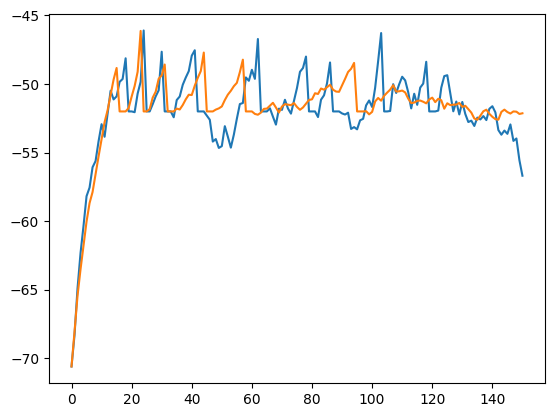

In [13]:
print(data_store.get_neuron_positions())
plt.plot(segs[0].get_vm(segs[0].get_stored_vm_ids()[0]))
plt.plot(segs2[0].get_vm(segs2[0].get_stored_vm_ids()[0]))
plt.show()